In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from tqdm.autonotebook import tqdm
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_2138/1003344669.py:9: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making


In [2]:
# # Calculate average Prob of best arm picking every bin
# def max_rew_arm(x:dict):
#     rew_list = np.array([x[key][0] for key in list(x.keys())])
#     return np.argmax(rew_list)

# def process_epoch_optimal_arm(x:list):
#     optimal_arm = [max_rew_arm(x[trail]) for trail in range(len(x)-1)]
#     return optimal_arm



In [3]:
TRIALS = 100
EPOCHS = 25
BINS = 10
LR = 0.1
NUM_ARMS = 2
SCALING_FACTOR = 100
TIME_STAMP_CHANGE = 50
STATIONARY = False
BIN_SIZE = TRIALS//BINS
BIN_CHANGE = TIME_STAMP_CHANGE // BIN_SIZE



# Define reward values for each arm
REWARD_VALUES = np.array([10, 10])/SCALING_FACTOR
REWARD_STD = np.array([2, 2])/SCALING_FACTOR

# Define initial probabilities for each arm
INITIAL_PROBS = np.array([0.8, 0.2])

# Define changed reward values (after time_stamp_change)
REWARD_VALUES_CHANGED = np.array([10, 10])/SCALING_FACTOR
REWARD_STD_CHANGED = np.array([2, 2])/SCALING_FACTOR

# Define changed probabilities (after time_stamp_change)
CHANGED_PROBS = np.array([0.2, 0.8])

# Set which parameters to change: 'reward', 'probability', or 'both' : Can change probs or rewards alone or both
CHANGE_TYPE = 'probability'



BEST_ARM_BEFORE = 0
BEST_ARM_AFTER = 1

BEST_ARM = torch.zeros((EPOCHS,TRIALS), dtype=int)
BEST_ARM[:,:TIME_STAMP_CHANGE] = BEST_ARM_BEFORE
BEST_ARM[:,TIME_STAMP_CHANGE:] = BEST_ARM_AFTER  



def process_prob(arm_chosen_monitor:list):  
    # Computing Accuracy
    prob_optimal = torch.zeros((EPOCHS, BINS))

    for i in range(BINS):
        start, end = i * BIN_SIZE, (i + 1) * BIN_SIZE
        correct_choices = torch.sum(arm_chosen_monitor[:, start:end] == BEST_ARM[:,start:end], axis = 1)
        prob_optimal[:, i] = (correct_choices / BIN_SIZE)

    prob_optimal_per_bin = torch.mean(prob_optimal,axis = 0)

    return prob_optimal_per_bin
    


In [4]:
env = ProbReversalEnv(
    num_arms = NUM_ARMS,
    mean_reward = REWARD_VALUES,
    std = REWARD_STD,
    probabilities = INITIAL_PROBS,
    mean_rew_change = REWARD_VALUES_CHANGED,
    std_change = REWARD_STD_CHANGED,
    probabilities_change = CHANGED_PROBS,
    time_stamp_change = TIME_STAMP_CHANGE,
    change_type = CHANGE_TYPE)


In [5]:
ARM_MONITOR = defaultdict(dict)
NUM_ARM_PICKS_MONITOR = defaultdict(dict)
DP_MONITOR = defaultdict(dict)
IP_MONITOR = defaultdict(dict)
REWARD_MONITOR = defaultdict(dict)
ARM_TRACKER = defaultdict(dict)
OPTIMAL_CHOICE_MONITOR = defaultdict(dict)
ACTUAL_CHOICE_MONITOR = defaultdict(dict)
PROB_OPTIMAL_MONITOR = defaultdict(dict)
LAST_BIN_PROB_MONITOR = defaultdict(dict)
PRE_CHANGE_PROB_MONITOR = defaultdict(dict)

In [ ]:
DEL_LIM_ARR = [0.1, 0.2, 0.5, 1.0] #0.01, 0.05,
VAR_ARR = [0.16, 0.01, 0.04, 0.26] # Normal, PD, STD DBS, Sector DBS

In [7]:
for var in tqdm(VAR_ARR):
    for del_lim in DEL_LIM_ARR:
        reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor, arm_tracker_full= train(env, 
                                                      trails = TRIALS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = BINS,
                                                      STN_data = None, #'rossler',
                                                      d1_amp=0.1,
                                                      d2_amp=0.01,#0.0075, 
                                                      gpi_threshold=0.2,
                                                      max_gpi_iters=50,
                                                      del_lim=del_lim, train_IP = False, 
                                                      del_med = None, printing = False,
                                                      gpi_mean= 1, ep_0 = var,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0, 
                                                      track_arms = True)
        

        ARM_MONITOR[var][del_lim] = arm_chosen_monitor
        REWARD_MONITOR[var][del_lim] = reward_monitor
        DP_MONITOR[var][del_lim] = dp_monitor
        IP_MONITOR[var][del_lim] = ip_monitor
        ARM_TRACKER[var][del_lim] = arm_tracker_full


        # OPTIMAL_CHOICE_ARRAY = np.array([process_epoch_optimal_prob(ARM_TRACKER[var][del_lim][epoch]) for epoch in range(len(ARM_TRACKER[var][del_lim]))])
        ACTUAL_CHOICE_ARRAY = np.array(ARM_MONITOR[var][del_lim])
        # NUMBER_OF_MATCHES = (OPTIMAL_CHOICE_ARRAY == ACTUAL_CHOICE_ARRAY)*1
        PROB = process_prob(ARM_MONITOR[var][del_lim]) #np.mean(NUMBER_OF_MATCHES,axis = 1)
        last_bin_prob = PROB[-1]
        pre_change_prob = PROB[4]


        # OPTIMAL_CHOICE_MONITOR[var][del_lim] = OPTIMAL_CHOICE_ARRAY
        ACTUAL_CHOICE_MONITOR[var][del_lim] = ACTUAL_CHOICE_ARRAY
        PROB_OPTIMAL_MONITOR[var][del_lim] = PROB
        LAST_BIN_PROB_MONITOR[var][del_lim] = last_bin_prob
        PRE_CHANGE_PROB_MONITOR[var][del_lim] = pre_change_prob
        print(f'del_lim = {del_lim} and var = {var}: last bin prob of optimal arm = {last_bin_prob}')




  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

del_lim = 0.05 and var = 0.16: last bin prob of optimal arm = 0.7440000176429749


  0%|          | 0/25 [00:00<?, ?it/s]

del_lim = 0.1 and var = 0.16: last bin prob of optimal arm = 1.0


...

del_lim = 0.2 and var = 0.26: last bin prob of optimal arm = 0.9959999918937683


  0%|          | 0/25 [00:00<?, ?it/s]

del_lim = 0.5 and var = 0.26: last bin prob of optimal arm = 1.0


  0%|          | 0/25 [00:00<?, ?it/s]

del_lim = 1.0 and var = 0.26: last bin prob of optimal arm = 0.9919999837875366


In [10]:
DEL_LIM_ARR_FILTERED = DEL_LIM_ARR
var = {'normal': VAR_ARR[0], 'PD': VAR_ARR[1], 'std_DBS': VAR_ARR[2], 'sector_DBS': VAR_ARR[3]}
Last_bin_Probs_PD = [LAST_BIN_PROB_MONITOR[var['PD']][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Last_bin_Probs_std_DBS = [LAST_BIN_PROB_MONITOR[var['std_DBS']][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Last_bin_Probs_sector_DBS = [LAST_BIN_PROB_MONITOR[var['sector_DBS']][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]

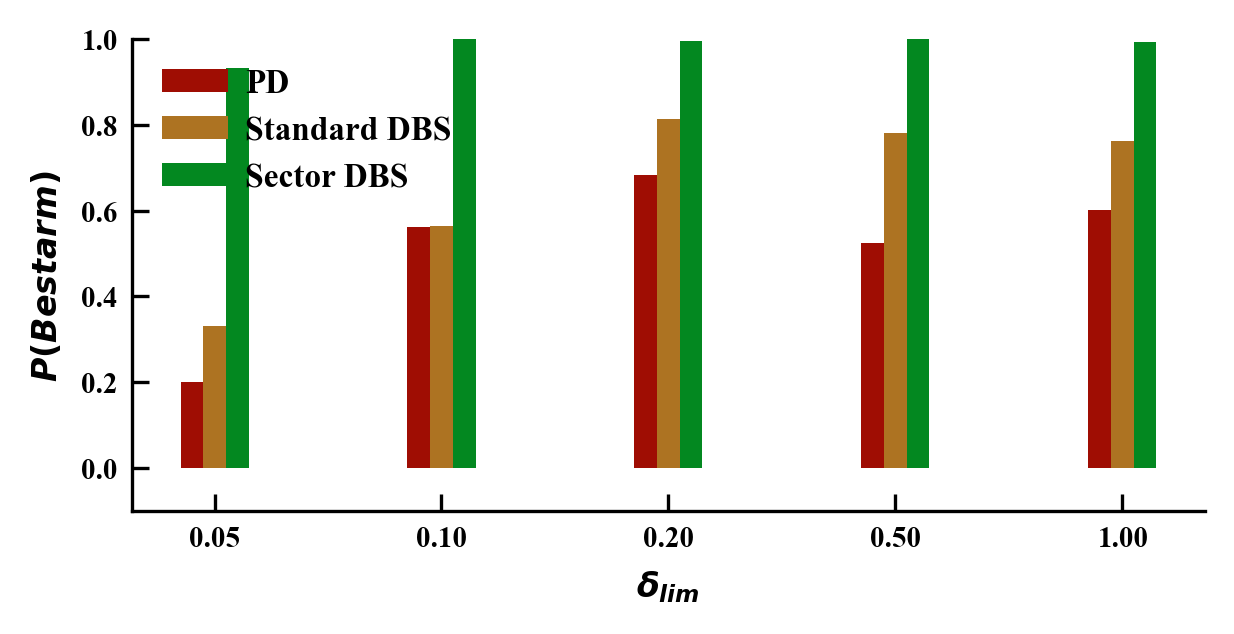

In [11]:
# plotting bar plot for each del lim on x axis and prob on y axis. Different colors for each var
bar_width = 0.1
x_values = np.arange(len(DEL_LIM_ARR_FILTERED))
alpha = 1

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ce",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}

plt.figure(figsize=(4,2))
plt.bar(x_values - bar_width, Last_bin_Probs_PD + np.abs(np.random.randn(len(Last_bin_Probs_PD))*0.01), width=bar_width, label="PD", alpha=alpha, color=colors['PD'], capsize=4)
plt.bar(x_values, Last_bin_Probs_std_DBS+ np.abs(np.random.randn(len(Last_bin_Probs_std_DBS))*0.01), width=bar_width, label="Standard DBS", alpha=alpha, color=colors['std_DBS'], capsize=4)
plt.bar(x_values + bar_width, Last_bin_Probs_sector_DBS, width=bar_width, label="Sector DBS", alpha=alpha, color = colors['sector_DBS'], capsize=4)
plt.legend()
plt.xticks(x_values, [f"{v:.2f}" for v in DEL_LIM_ARR_FILTERED], rotation=0)
plt.xlabel('$\delta_{lim}$')
plt.ylabel('$P(Best arm)$')
plt.ylim(-0.1, 1)
plt.show()